## 1-   Project Overview
This project analyzes marketing analytics data to explore customer behavior, engagement patterns, and predict conversion outcomes.

## 2- Import Libraries

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SQL Connection
# from sqlalchemy import create_engine

# Machine Learning
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


## 3- Database Connection & Data Loading
- 3.1 SQL Server Connection
- 3.2 Load Data from Views
- 3.3 Quick Check

In [267]:
from sqlalchemy import create_engine

server = "DESKTOP-NVTG305"
database = "MarketingAnalytics"

# Create Connection
engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver=ODBC Driver 17 for SQL Server&trusted_connection=yes"
)

print("Connection to SQL Server established successfully")

Connection to SQL Server established successfully


In [268]:
# Dimensions Tables
customers = pd.read_sql("SELECT * FROM vw_customers_final", engine)
products = pd.read_sql("SELECT * FROM vw_products_final", engine)
geography = pd.read_sql("SELECT * FROM vw_geography_final", engine)

# Facts Tables
engagements = pd.read_sql("SELECT * FROM vw_engagement_data_final", engine)
journey = pd.read_sql("SELECT * FROM vw_customer_journey_cta", engine)
reviews = pd.read_sql("SELECT * FROM vw_customer_reviews_final", engine)

print("All Views loaded successfully!")

All Views loaded successfully!


In [269]:
# Checks
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Geography:", geography.shape)
print("Engagements:", engagements.shape)
print("Journey:", journey.shape)
print("Reviews:", reviews.shape)

Customers: (100, 6)
Products: (20, 4)
Geography: (10, 3)
Engagements: (4623, 9)
Journey: (3932, 7)
Reviews: (1363, 6)


## 4- Data Overview & Initial Inspection
- 4.1 Dataset Preview
- 4.2 Data Types
- 4.3 Summary Statistics

In [270]:
customers.sample(5)

,CustomerID,CustomerName,Email,Gender,Age,GeographyID
50,51,Michael Davis,michael.davis@example.com,Female,63,10
48,49,Michael Smith,michael.smith@example.com,Female,61,4
83,84,Michael Williams,michael.williams@example.com,Female,34,4
29,30,Alex Garcia,alex.garcia@example.com,Female,33,7
41,42,John Gonzalez,john.gonzalez@example.com,Female,69,1


In [271]:
# engagements.sample(5)
engagements.dtypes

EngagementID       int64
ContentID          int64
ContentType       object
Likes              int64
CampaignID         int64
EngagementDate    object
productID          int64
Views              int64
Clicks             int64
dtype: object

In [272]:
journey.sample(5)

,JourneyID,CustomerID,ProductID,VisitDate,Action,Duration,Stage_Clean
1071,1371,31,17,2024-03-16,View,256.0,Home Page
2517,3922,68,5,2023-11-13,Click,165.0,Product Page
3875,2451,99,13,2024-07-13,View,73.0,Product Page
646,2075,21,9,2024-07-09,Drop-off,0.0,Checkout
3917,429,100,15,2023-04-02,Click,97.0,Home Page


In [273]:
reviews.sample(5)

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText
5,6,81,1,2025-12-21,4,Customer support was very helpful.
562,563,86,13,2025-02-27,4,"Good quality, but could be cheaper."
69,70,93,5,2024-01-30,4,Shipping was fast and the item was we...
608,609,40,10,2025-10-23,3,"Average experience, nothing special."
837,838,61,17,2024-04-21,5,Shipping was fast and the item was we...


In [274]:
engagements.describe()

,EngagementID,ContentID,Likes,CampaignID,productID,Views,Clicks
count,4623.000000,4623.000000,4623.000000,4623.000000,4623.000000,4623.000000,4623.000000
mean,2312.000000,25.426130,114.368592,10.660826,10.424616,2544.795587,497.936621
std,1334.689477,14.292613,205.083859,5.770570,5.795959,2188.899289,667.403489
min,1.000000,1.000000,0.000000,1.000000,1.000000,10.000000,0.000000
25%,1156.500000,13.000000,3.000000,6.000000,5.000000,780.500000,50.000000
50%,2312.000000,25.000000,28.000000,11.000000,10.000000,1885.000000,229.000000
75%,3467.500000,38.000000,131.000000,16.000000,15.000000,3881.500000,685.500000
max,4623.000000,50.000000,1977.000000,20.000000,20.000000,9759.000000,4574.000000


In [275]:
journey.describe()

,JourneyID,CustomerID,ProductID,Duration
count,3932.000000,3932.000000,3932.000000,3932.000000
mean,1966.500000,53.049593,10.442014,132.978128
std,1135.214958,28.354038,5.840668,95.100782
min,1.000000,1.000000,1.000000,0.000000
25%,983.750000,29.000000,5.000000,44.000000
50%,1966.500000,54.000000,10.000000,133.000000
75%,2949.250000,78.000000,16.000000,216.000000
max,3932.000000,100.000000,20.000000,300.000000


In [276]:
reviews.describe()

,ReviewID,CustomerID,ProductID,Rating
count,1363.00000,1363.000000,1363.000000,1363.000000
mean,682.00000,51.701394,10.337491,3.686720
std,393.60852,28.605493,5.702922,1.180243
min,1.00000,1.000000,1.000000,1.000000
25%,341.50000,27.000000,5.000000,3.000000
50%,682.00000,53.000000,10.000000,4.000000
75%,1022.50000,77.000000,15.000000,5.000000
max,1363.00000,100.000000,20.000000,5.000000


## 5- Data Quality Checks
- 5.1 Missing Values
- 5.2 Duplicates
- 5.3 Outliers

In [277]:
customers.isnull().sum()

CustomerID      0
CustomerName    0
Email           0
Gender          0
Age             0
GeographyID     0
dtype: int64

In [278]:
products.isnull().sum()

ProductID      0
ProductName    0
Category       0
Price          0
dtype: int64

In [279]:
journey.isnull().sum()

JourneyID      0
CustomerID     0
ProductID      0
VisitDate      0
Action         0
Duration       0
Stage_Clean    0
dtype: int64

In [280]:
engagements.isnull().sum()
engagements.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4623 entries, 0 to 4622
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   EngagementID    4623 non-null   int64 
 1   ContentID       4623 non-null   int64 
 2   ContentType     4623 non-null   object
 3   Likes           4623 non-null   int64 
 4   CampaignID      4623 non-null   int64 
 5   EngagementDate  4623 non-null   object
 6   productID       4623 non-null   int64 
 7   Views           4623 non-null   int64 
 8   Clicks          4623 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 325.2+ KB


In [281]:
reviews.isnull().sum()

ReviewID      0
CustomerID    0
ProductID     0
ReviewDate    0
Rating        0
ReviewText    0
dtype: int64

In [282]:
journey['JourneyID'].duplicated().sum()

np.int64(0)

In [283]:
engagements['EngagementID'].duplicated().sum()

np.int64(0)

In [284]:
reviews['ReviewID'].duplicated().sum()

np.int64(0)

In [285]:
engagements.dtypes

EngagementID       int64
ContentID          int64
ContentType       object
Likes              int64
CampaignID         int64
EngagementDate    object
productID          int64
Views              int64
Clicks             int64
dtype: object

In [286]:
journey.dtypes

JourneyID        int64
CustomerID       int64
ProductID        int64
VisitDate       object
Action          object
Duration       float64
Stage_Clean     object
dtype: object

In [287]:
engagements_numeric = engagements.select_dtypes('int64').corr()
engagements_numeric

,EngagementID,ContentID,Likes,CampaignID,productID,Views,Clicks
EngagementID,1.000000,-0.006400,0.007480,0.019055,0.021415,0.004361,0.001107
ContentID,-0.006400,1.000000,0.017370,-0.007211,-0.017286,0.009770,0.017529
Likes,0.007480,0.017370,1.000000,0.018061,0.009242,0.740202,0.906635
CampaignID,0.019055,-0.007211,0.018061,1.000000,0.001571,0.024050,0.024769
productID,0.021415,-0.017286,0.009242,0.001571,1.000000,0.000665,0.004202
Views,0.004361,0.009770,0.740202,0.024050,0.000665,1.000000,0.848697
Clicks,0.001107,0.017529,0.906635,0.024769,0.004202,0.848697,1.000000


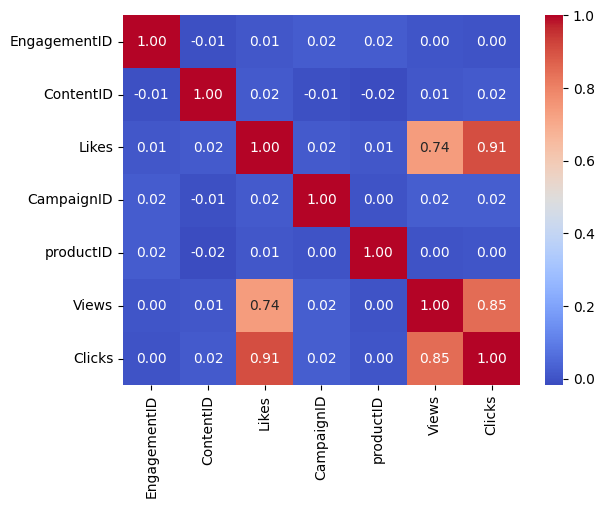

In [288]:
sns.heatmap(engagements_numeric, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

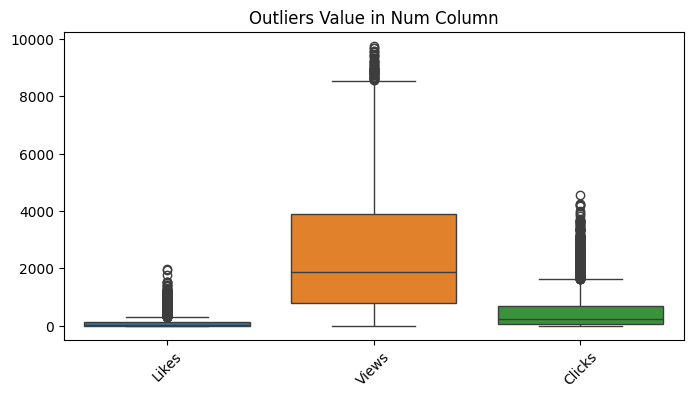

In [289]:
engagements_num_cols = ['Likes' , 'Views' , 'Clicks']

plt.figure(figsize=(8,4))
sns.boxplot(engagements[engagements_num_cols])
plt.xticks(rotation=45)
plt.title('Outliers Value in Num Column')
plt.show()

array([[<Axes: title={'center': 'Likes'}>,
        <Axes: title={'center': 'Views'}>],
       [<Axes: title={'center': 'Clicks'}>, <Axes: >]], dtype=object)

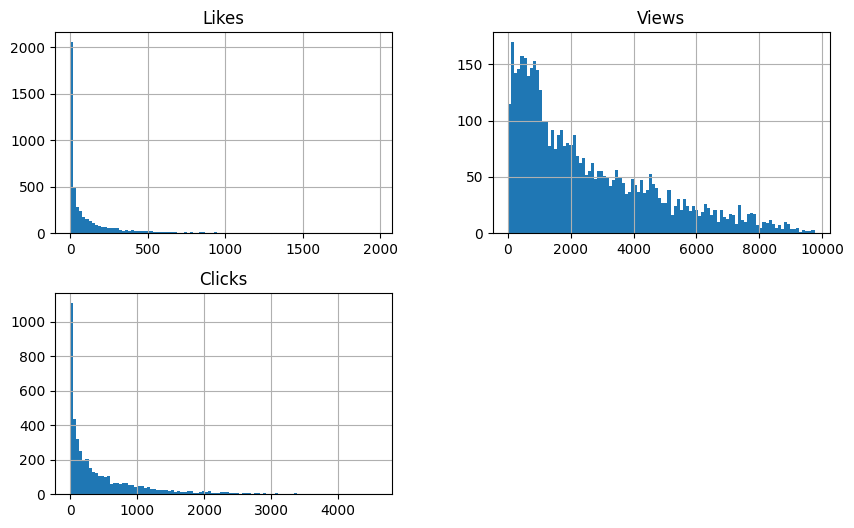

In [290]:
engagements[engagements_num_cols].hist(bins=100, figsize=(10,6))

## 6-  Exploratory Data Analysis (EDA)
- 6.1 Customer Demographics
- 6.2 Product Performance
- 6.3 Engagement Analysis
- 6.4 Conversion Analysis

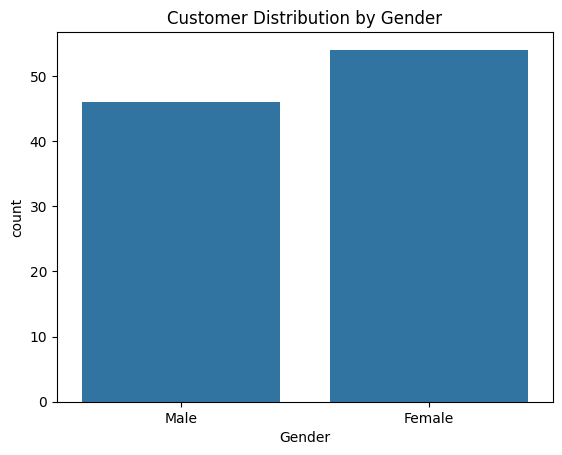

In [291]:
sns.countplot(data=customers, x="Gender")
plt.title("Customer Distribution by Gender")
plt.show()

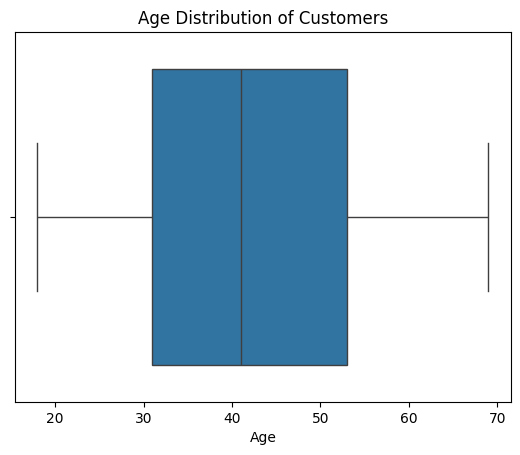

In [292]:
sns.boxplot(data=customers, x="Age")
plt.title("Age Distribution of Customers")
plt.show()

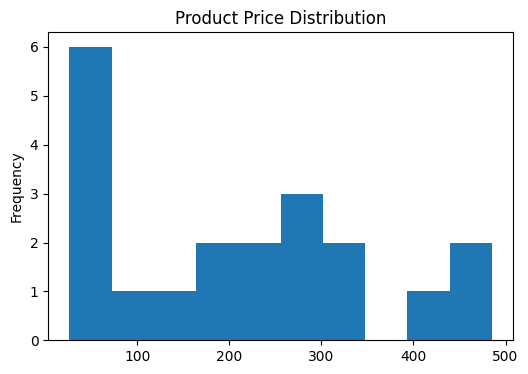

In [293]:
products["Price"].plot(kind="hist", figsize=(6,4))
plt.title("Product Price Distribution")
plt.show()

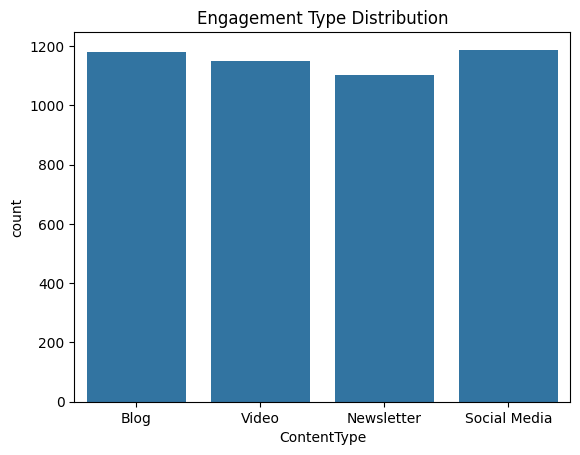

In [294]:
sns.countplot(data=engagements, x="ContentType")
plt.title("Engagement Type Distribution")
plt.show()

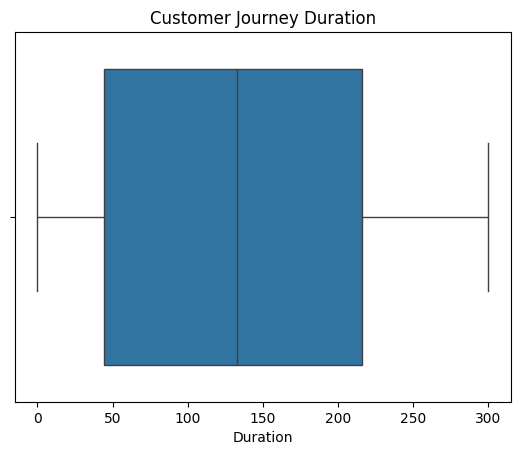

In [295]:
sns.boxplot(data=journey, x="Duration")
plt.title("Customer Journey Duration")
plt.show()

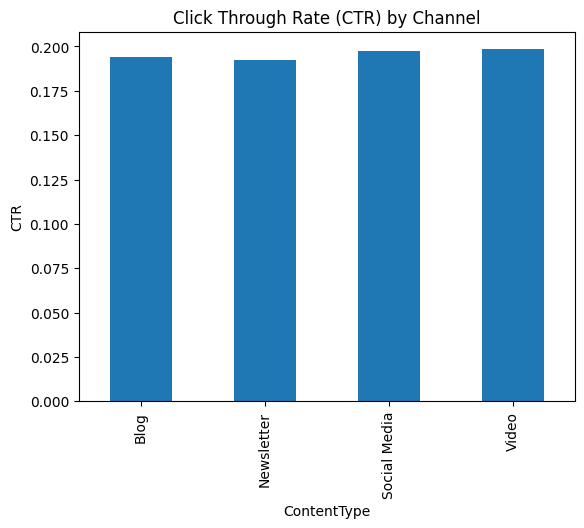

In [296]:
ctr = engagements.groupby("ContentType").apply(
    lambda x: x['Clicks'].sum() / x['Views'].sum()
)

ctr.plot(kind="bar")
plt.title("Click Through Rate (CTR) by Channel")
plt.ylabel("CTR")
plt.show()

In [297]:
funnel = engagements[['Views','Clicks','Likes']].sum()
funnel

Views     11764590
Clicks     2301961
Likes       528726
dtype: int64

In [298]:
engagements.groupby('ContentType')[['Views','Clicks']].mean()

,Views,Clicks
ContentType,,
Blog,2664.575424,517.456780
Newsletter,2432.349638,468.252717
Social Media,2605.143098,514.109428
Video,2467.564726,489.703736


## 6- Data Preparation 
- 6.1 Encoding & Scaling

In [299]:
engagements.dtypes

EngagementID       int64
ContentID          int64
ContentType       object
Likes              int64
CampaignID         int64
EngagementDate    object
productID          int64
Views              int64
Clicks             int64
dtype: object

In [300]:
engagements.columns.tolist()

['EngagementID',
 'ContentID',
 'ContentType',
 'Likes',
 'CampaignID',
 'EngagementDate',
 'productID',
 'Views',
 'Clicks']

In [301]:
engagements.nunique().sort_values(ascending=True)

ContentType          4
CampaignID          20
productID           20
ContentID           50
Likes              640
EngagementDate    1085
Clicks            1483
Views             3151
EngagementID      4623
dtype: int64

In [302]:
from sklearn.preprocessing import LabelEncoder

cat_eng_cols = engagements.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in cat_eng_cols:
    engagements[col] = le.fit_transform(engagements[col])

engagements.head()

,EngagementID,ContentID,ContentType,Likes,CampaignID,EngagementDate,productID,Views,Clicks
0,1,39,0,190,1,238,9,1883,671
1,2,48,0,114,18,85,20,5280,532
2,3,16,3,32,7,337,14,1905,204
3,4,43,3,17,19,744,20,2766,257
4,5,16,1,306,6,412,15,5116,1524


In [303]:
from sklearn.preprocessing import StandardScaler

scl_eng_cols = ['ContentType',
 'Likes',
 'CampaignID',
 'EngagementDate',
 'Views',]

scaler = StandardScaler()
engagements[scl_eng_cols] = scaler.fit_transform(engagements[scl_eng_cols])

In [304]:
engagements.head()

,EngagementID,ContentID,ContentType,Likes,CampaignID,EngagementDate,productID,Views,Clicks
0,1,39,-1.336847,0.368823,-1.674336,-0.995692,9,-0.302374,671
1,2,48,-1.336847,-0.001797,1.271966,-1.483461,20,1.249715,532
2,3,16,1.337426,-0.401677,-0.634465,-0.680076,14,-0.292323,204
3,4,43,1.337426,-0.474826,1.445278,0.617454,20,0.101068,257
4,5,16,-0.445423,0.934506,-0.807776,-0.440974,15,1.174783,1524


## 9- ML Predictive Modeling

### Conversion Prediction

In [305]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

In [306]:
engagements['EngagementDate'] = pd.to_datetime(engagements['EngagementDate'])
engagements['day_of_week'] = engagements['EngagementDate'].dt.dayofweek
engagements['month'] = engagements['EngagementDate'].dt.month

In [307]:
engagements['converted'] = (engagements['Clicks'] > 0).astype(int) 

In [308]:
engagements['converted'].value_counts(normalize=True)

converted
1    0.996106
0    0.003894
Name: proportion, dtype: float64

In [309]:
X = engagements[['ContentType','Likes','CampaignID','Views']]
y = engagements['converted']

X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42, stratify=y
)

In [310]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [311]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [312]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy : {accuracy:.4f}")

Logistic Regression Accuracy : 0.9157


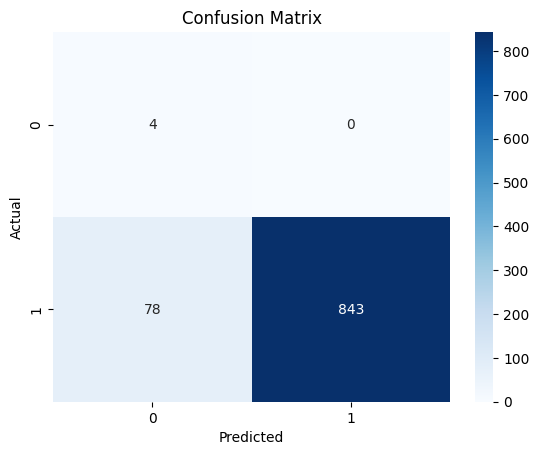

In [313]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Engagement Score Prediction

In [316]:
engagements['engagement_level'] = pd.qcut(
    engagements['Likes'] + engagements['Clicks'], 
    q=3,
    labels=['Low','Medium','High']
)

In [317]:
X = engagements[['Likes','Views','ContentType','CampaignID']]
y = engagements['engagement_level']

In [319]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X , y, test_size=0.2, random_state=42, stratify=y
)

In [320]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42, n_estimators=200)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [323]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.91      0.92      0.91       308
         Low       0.94      0.94      0.94       308
      Medium       0.86      0.85      0.86       309

    accuracy                           0.90       925
   macro avg       0.90      0.90      0.90       925
weighted avg       0.90      0.90      0.90       925



In [327]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy : {accuracy:.4f}")

Logistic Regression Accuracy : 0.9049


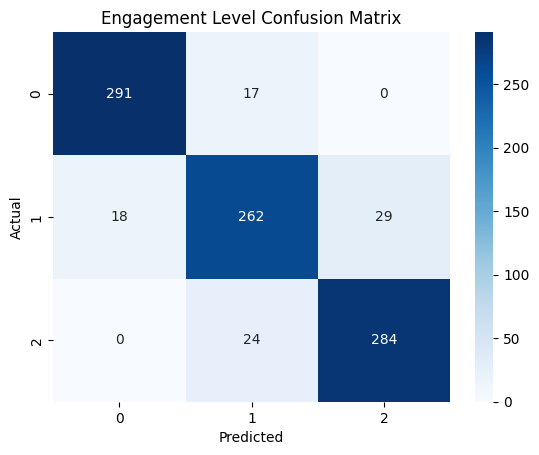

In [324]:
cm = confusion_matrix(y_test, y_pred, labels=['Low','Medium','High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Engagement Level Confusion Matrix')
plt.show()

Top Features Impacting Engagement:

0    0.582796
1    0.347624
3    0.048054
2    0.021525
dtype: float64


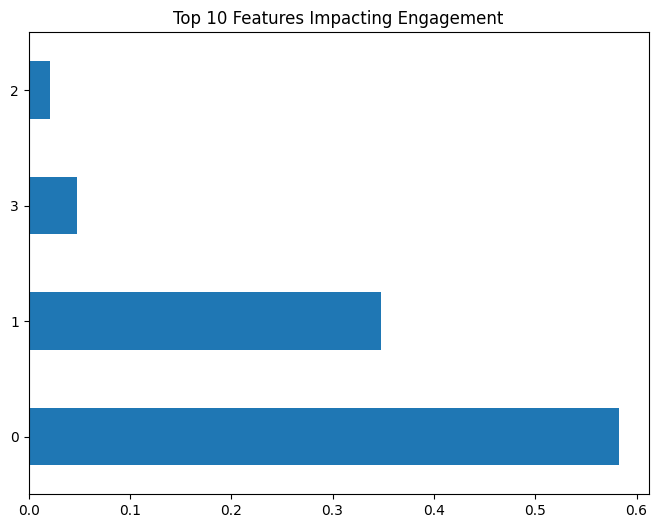

In [326]:
importance = pd.Series(model.feature_importances_).sort_values(ascending=False)
print("Top Features Impacting Engagement:\n")
print(importance.head(10))

# Visualization
importance.head(10).plot(kind='barh', figsize=(8,6))
plt.title('Top 10 Features Impacting Engagement')
plt.show()